# A control-barrier-function safety filter with PIQP, nested inside the controller

A unicycle robot is driven towards a goal by a simple nominal controller that knows nothing about
the three obstacles in its way. A **safety filter** sits between the controller and the robot: at
every step it solves a small quadratic program that returns the admissible input closest to the
nominal one, where "admissible" is defined by control barrier functions (Ames et al., 2017).

What Scaly contributes:

| Scaly feature | Where |
| --- | --- |
| `sc.jacobian` of expressions | the Lie derivatives $\nabla h^\top g$ in the constraints, never derived by hand |
| `sc.opt.problem` + `sc.opt.solver(..., "piqp")` | the QP, which Scaly *proves* is quadratic with affine constraints |
| calling a solver with `Expr` leaves | the QP solve nested inside the `controller` `Function` |
| one shared library, one C function | nominal law + QP oracles + PIQP wrapper, rendered by `write_module` |

This notebook needs the vendored PIQP. The script version is `examples/cbf_safety_filter.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "cbf_safety_filter"

## Barriers on a look-ahead point

The unicycle $(x, y, \psi)$ with input $u = (v, \omega)$ has $\dot x = v\cos\psi$, $\dot y = v\sin\psi$,
$\dot\psi = \omega$. Its position does not depend on $\omega$ directly, so a barrier on the position
alone would have relative degree two in the turn rate. The standard fix is a *look-ahead point*
$p = (x, y) + d(\cos\psi, \sin\psi)$ at distance $d$ ahead, whose velocity is input-affine with an
invertible input matrix:

$$
\dot p = g(\psi)\, u, \qquad g(\psi) = \frac{\partial p}{\partial (x, y, \psi)} \frac{\partial (\dot x, \dot y, \dot\psi)}{\partial u}
= \begin{pmatrix} \cos\psi & -d\sin\psi \\ \sin\psi & d\cos\psi \end{pmatrix}.
$$

Each obstacle $i$ (centre $o_i$, radius $r_i$) gives a barrier $h_i(p) = \lVert p - o_i\rVert^2 - r_i^2$,
positive outside. Requiring $\dot h_i \ge -\gamma h_i$ keeps $h_i \ge 0$ for all time, and
$\dot h_i = \nabla h_i(p)^\top g(\psi)\, u$ is **linear in $u$**. In code, `input_matrix` computes
$g$ exactly as the formula reads, as the product of two Jacobians.

In [2]:
LOOKAHEAD, GAMMA, DT, STEPS = 0.3, 2.0, 0.02, 600
U_MAX = np.array([1.0, 3.0])  # speed, turn rate
WEIGHT = np.array([1.0, 0.05])  # deviating in turn rate is cheap
OBSTACLES = np.array([[1.5, 0.3, 0.5], [3.0, -0.5, 0.4], [3.3, 0.8, 0.35]])
GOAL = np.array([4.5, 0.0])


def lookahead(state):
  return sc.stack([state[0] + LOOKAHEAD * state[2].cos(), state[1] + LOOKAHEAD * state[2].sin()])


def input_matrix(state):
  u = sc.sym("u", 2)
  state_rate = sc.stack([u[0] * state[2].cos(), u[0] * state[2].sin(), u[1]])
  return sc.jacobian(lookahead(state), state) @ sc.jacobian(state_rate, u)


def barriers(p):
  return sc.stack([(p[0] - ox) ** 2 + (p[1] - oy) ** 2 - r**2 for ox, oy, r in OBSTACLES])

## The QP

$$
\min_u\ \lVert u - u_{\text{nom}}\rVert_W^2 \quad\text{s.t.}\quad \nabla h_i(p)^\top g(\psi)\,u + \gamma h_i(p) \ge 0 \ (i = 1,2,3), \qquad |u| \le u_{\max}.
$$

The state and the nominal input are parameters. PIQP accepts only problems Scaly can prove to be
QPs: when the solver is built, Scaly checks that the Hessian of the cost and the Jacobian of the
constraints do not depend on the variables $u$ (they depend on the parameters, which is fine), and
extracts $P, c, G, h$ as generated functions of the parameters. The tolerances are tightened so that
the solution sits on active bounds to within $10^{-10}$.

In [3]:
@sc.opt.problem(vars=sc.L("u", 2), params=sc.G(sc.L("state", 3), sc.L("u_nom", 2)))
def safety_filter(u, params):
  state, u_nom = params
  p = lookahead(state)
  h = barriers(p)
  lie = sc.jacobian(h, p) @ input_matrix(state)  # (obstacles, 2)
  return sc.opt.ProblemSpec(
    minimize=(sc.const(WEIGHT) * (u - u_nom) ** 2).sum(),
    ineq=(sc.opt.bounded(lie @ u + GAMMA * h, lo=0.0, name="cbf"),),
    lb=sc.const(-U_MAX),
    ub=sc.const(U_MAX),
  )


TIGHT = {"eps_abs": 1e-10, "eps_rel": 1e-10, "eps_duality_gap_abs": 1e-10, "eps_duality_gap_rel": 1e-10}
filter_qp = sc.opt.solver(safety_filter, sc.opt.PIQP(options=TIGHT), name="cbf_qp")

## The controller, with the filter inside

The nominal law steers the look-ahead point straight at the goal, $u_{\text{nom}} = g^{-1}(-k(p - p_{\text{goal}}))$,
saturated. The `controller` computes it and then **calls the QP solver on expressions**: the
solver becomes a node in the controller's graph, and the controller, the QP's oracles and the
PIQP wrapper compile into one shared library. It also returns the barrier values for plotting.

In [4]:
def nominal(state):
  g = input_matrix(state)
  pdot = -1.5 * (lookahead(state) - sc.const(GOAL))
  det = g[0, 0] * g[1, 1] - g[0, 1] * g[1, 0]
  u = sc.stack([g[1, 1] * pdot[0] - g[0, 1] * pdot[1], g[0, 0] * pdot[1] - g[1, 0] * pdot[0]]) / det
  return sc.minimum(sc.maximum(u, sc.const(-U_MAX)), sc.const(U_MAX))


@sc.function(3, output=sc.G("u", "u_nom", "h"))
def controller(state):
  u_nom = nominal(state)
  zeros = sc.const(np.zeros(2))
  u, *_ = filter_qp(zeros, zeros, sc.const(np.zeros(0)), sc.const(np.zeros(len(OBSTACLES))), (state, u_nom))
  return u, u_nom, barriers(lookahead(state))


@sc.function(3, output=sc.G("u", "h"))
def unfiltered(state):
  return nominal(state), barriers(lookahead(state))

## Closed loop, with and without the filter

In [5]:
def run(policy):
  state = np.zeros(3)
  log = {"state": [], "u": [], "u_nom": [], "h": []}
  for _ in range(STEPS):
    out = policy(state)
    u, h = out[0], out[-1]
    log["state"].append(state)
    log["u"].append(u)
    log["u_nom"].append(out[1] if len(out) == 3 else u)
    log["h"].append(h)
    state = state + DT * np.array([u[0] * np.cos(state[2]), u[0] * np.sin(state[2]), u[1]])
  return {k: np.array(v) for k, v in log.items()}


safe, unsafe = run(controller), run(unfiltered)
print(f"smallest barrier value: {safe['h'].min():.4f} with the filter, {unsafe['h'].min():.4f} without")
print(f"filter active (input changed by more than 1e-3) at {np.sum(np.abs(safe['u'] - safe['u_nom']).max(axis=1) > 1e-3)} of {STEPS} steps")

smallest barrier value: 0.0345 with the filter, -0.1600 without
filter active (input changed by more than 1e-3) at 150 of 600 steps


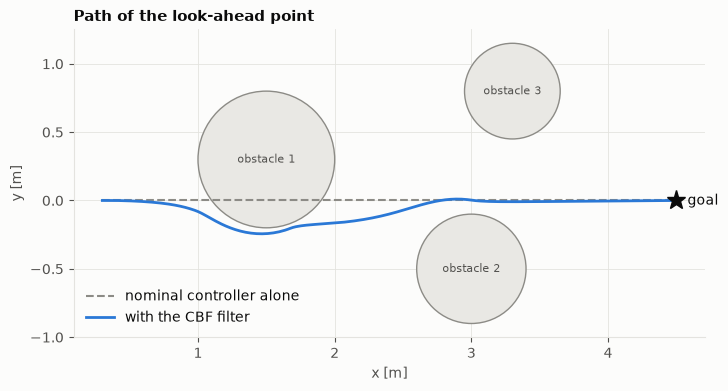

In [6]:
def lookahead_np(states):
  return states[:, :2] + LOOKAHEAD * np.stack([np.cos(states[:, 2]), np.sin(states[:, 2])], axis=1)


fig, ax = plt.subplots(figsize=(8, 3.8))
for i, (ox, oy, r) in enumerate(OBSTACLES):
  ax.add_patch(Circle((ox, oy), r, facecolor="#e9e8e4", edgecolor=plotstyle.NEUTRAL, lw=1))
  ax.annotate(f"obstacle {i + 1}", (ox, oy), ha="center", va="center", fontsize=8, color=plotstyle.TEXT_SECONDARY)
pu, ps = lookahead_np(unsafe["state"]), lookahead_np(safe["state"])
ax.plot(pu[:, 0], pu[:, 1], "--", color=plotstyle.NEUTRAL, lw=1.5, label="nominal controller alone")
ax.plot(ps[:, 0], ps[:, 1], color=plotstyle.BLUE, lw=2, label="with the CBF filter")
ax.plot(*GOAL, "*", ms=14, color=plotstyle.TEXT)
ax.annotate("goal", GOAL, xytext=(8, -3), textcoords="offset points")
ax.set_aspect("equal")
ax.set_title("Path of the look-ahead point")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.legend(loc="lower left")
plt.show()

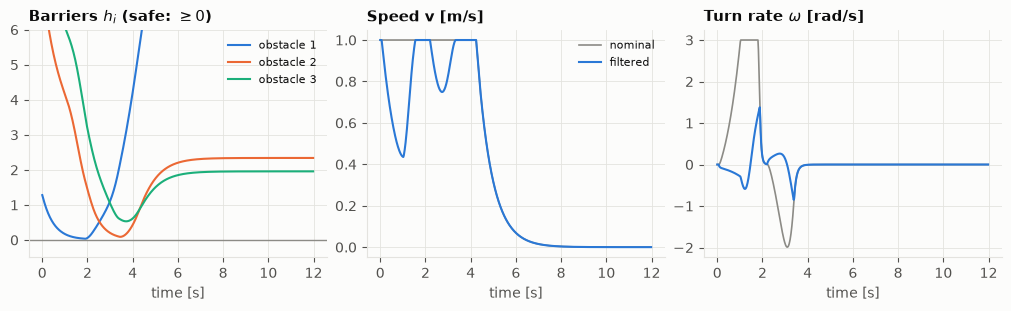

In [7]:
t = DT * np.arange(STEPS)
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True)
for i in range(len(OBSTACLES)):
  axes[0].plot(t, safe["h"][:, i], color=plotstyle.SERIES[i], lw=1.5, label=f"obstacle {i + 1}")
axes[0].axhline(0, color=plotstyle.NEUTRAL, lw=1)
axes[0].set_ylim(-0.5, 6)
axes[0].set_title(r"Barriers $h_i$ (safe: $\geq 0$)")
axes[0].legend(fontsize=8)
for ax, j, name in ((axes[1], 0, "Speed v [m/s]"), (axes[2], 1, r"Turn rate $\omega$ [rad/s]")):
  ax.plot(t, safe["u_nom"][:, j], color=plotstyle.NEUTRAL, lw=1.2, label="nominal")
  ax.plot(t, safe["u"][:, j], color=plotstyle.BLUE, lw=1.5, label="filtered")
  ax.set_title(name)
  ax.set_xlabel("time [s]")
axes[0].set_xlabel("time [s]")
axes[1].legend(fontsize=8)
plt.show()

The barriers approach zero but never cross it; the filter trades speed for turn rate, since the
weight on deviating in $\omega$ is twenty times smaller than in $v$. Without the filter the robot
drives straight through obstacle 1.

## What the QP looks like at one step

At a step where the filter is active, the feasible set in the $(v, \omega)$ plane is the input box
cut by one half-plane per obstacle (here only the nearest obstacle's half-plane reaches into the
box). The nominal input lies outside it; the filtered input is its $W$-weighted projection onto the
feasible set, which is why it moves mostly in $\omega$.

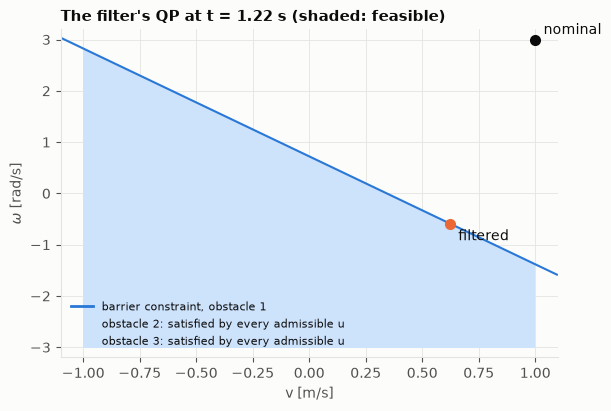

In [8]:
k = int(np.argmax(np.abs(safe["u"] - safe["u_nom"]).max(axis=1)))
state, u_nom, u_star = safe["state"][k], safe["u_nom"][k], safe["u"][k]
p = lookahead_np(state[None])[0]
g = np.array([[np.cos(state[2]), -LOOKAHEAD * np.sin(state[2])], [np.sin(state[2]), LOOKAHEAD * np.cos(state[2])]])
v_grid, w_grid = np.meshgrid(np.linspace(-1.1, 1.1, 400), np.linspace(-3.2, 3.2, 400))
fig, ax = plt.subplots(figsize=(6, 4))
feasible = (np.abs(v_grid) <= U_MAX[0]) & (np.abs(w_grid) <= U_MAX[1])
for i, (ox, oy, r) in enumerate(OBSTACLES):
  a = 2 * (p - [ox, oy]) @ g
  b = GAMMA * (np.sum((p - [ox, oy]) ** 2) - r**2)
  margin = a[0] * v_grid + a[1] * w_grid + b
  feasible &= margin >= 0
  if margin.min() < 0:  # the boundary crosses the window
    ax.contour(v_grid, w_grid, margin, levels=[0], colors=[plotstyle.SERIES[i]], linewidths=1.5)
    ax.plot([], [], color=plotstyle.SERIES[i], label=f"barrier constraint, obstacle {i + 1}")
  else:
    ax.plot([], [], " ", label=f"obstacle {i + 1}: satisfied by every admissible u")
ax.contourf(v_grid, w_grid, feasible, levels=[0.5, 1.5], colors=["#cde2fb"])
ax.plot(*u_nom, "o", color=plotstyle.TEXT, ms=7)
ax.annotate("nominal", u_nom, xytext=(6, 4), textcoords="offset points")
ax.plot(*u_star, "o", color=plotstyle.ORANGE, ms=7)
ax.annotate("filtered", u_star, xytext=(6, -12), textcoords="offset points")
ax.set_xlabel("v [m/s]")
ax.set_ylabel(r"$\omega$ [rad/s]")
ax.set_title(f"The filter's QP at t = {t[k]:.2f} s (shaded: feasible)")
ax.legend(loc="lower left", fontsize=8)
plt.show()

## One C function for the whole controller

`write_module(controller, ...)` renders the nominal law, the QP oracles and the PIQP wrapper as one
translation unit exposing one function, `controller(arg, res, iw, w, mem)`. It links against the
vendored `libpiqpc`; the flags are on the module.

In [9]:
from scaly.opt.external.graph import solver_backends_used

module = write_module(controller, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines; solver backends reached: {solver_backends_used(controller)}")
print("link with:", " ".join(flag for flag in module.link_flags if flag.startswith("-l")))

controller.c: 312 lines; solver backends reached: ('piqp',)
link with: -lpiqpc
